# libKriging vs RobustGaSP (R)

This notebook compares **rlibkriging** and **RobustGaSP** along two axes:

1. **Mimicry**: reproduce with `rlibkriging` a "default" Kriging fit
   equivalent to `RobustGaSP::rgasp()` under plain maximum likelihood
   (Matern 5/2 kernel, constant trend), and check that both give
   near-identical predictions.
2. **Package-specific feature**: RobustGaSP's signature contribution (Gu,
   Wang & Berger, 2018, *Annals of Statistics*) is **robust parameter
   estimation** via the *marginal posterior mode* under a *jointly robust
   prior* (`method = "post_mode"`, the package's default) rather than plain
   MLE. This tames a well-known failure mode of GP hyperparameter
   estimation on small/sparse designs: the profile likelihood can be nearly
   flat along some directions, so plain MLE range estimates can blow up
   (or collapse) wildly depending on the random restart. `rlibkriging`'s
   `objective = "LMP"` (Log Marginal Posterior) implements the same idea.

Steps:
1. Load rlibkriging and RobustGaSP
2. Branin 2D function + LHS design
3. Mimicry: `Kriging(objective = "LL")` vs `rgasp(method = "mle")` — same
   settings, overlaid cross-section comparison
4. Package-specific feature: robust estimation — `rgasp(method =
   "post_mode")` vs `Kriging(objective = "LMP")`, on a deliberately sparse
   design where plain MLE misbehaves
5. Argument correspondence table


## 0. Installation (run once)

Requires `rlibkriging` (built from this repository's sources, see
`tools/r-linux-macos/build.sh`) and the CRAN package `RobustGaSP`.

In [1]:
# Build rlibkriging once if not already built.
repo_root <- normalizePath(file.path(getwd(), "../.."), mustWork = FALSE)
rlibs     <- file.path(repo_root, "bindings", "R", "Rlibs", "rlibkriging")

if (!dir.exists(rlibs)) {
  message("Building rlibkriging from source...")
  ret <- system(paste0("cd '", repo_root, "' && bash tools/r-linux-macos/build.sh"))
  if (ret != 0) stop("Build failed - check compiler and cmake installation.")
} else {
  message("rlibkriging already built, skipping.")
}

if (!requireNamespace("RobustGaSP", quietly = TRUE)) {
  install.packages("RobustGaSP", repos = "https://cloud.r-project.org")
}


rlibkriging already built, skipping.



## 1. Load both packages

In [2]:
repo_root <- normalizePath(file.path(getwd(), "../.."), mustWork = FALSE)
lib_path  <- file.path(repo_root, "bindings", "R", "Rlibs")
library(rlibkriging, lib.loc = lib_path)
library(RobustGaSP)


dans la méthode pour ‘simulate’ avec la signature ‘"WarpKriging"’ : aucune définition de la classe “WarpKriging” n'est trouvée




Attachement du package : ‘rlibkriging’




L'objet suivant est masqué depuis ‘package:stats’:

    kernel




Les objets suivants sont masqués depuis ‘package:base’:

    beta, load, save




#########



...

## Copyright (C) 2016-2026 Mengyang Gu, Jesus Palomo and James O. Berger



#########




Attachement du package : ‘RobustGaSP’




L'objet suivant est masqué _par_ ‘.GlobalEnv’:

    simulate




L'objet suivant est masqué depuis ‘package:stats’:

    simulate




## 2. Branin function and design of experiments

Same test function and same LHS design as in the other notebooks of this
repository, so that the comparison only involves the packages themselves.

In [3]:
branin <- function(x) {
  if (!is.matrix(x)) x <- matrix(x, nrow = 1)
  x1 <- x[, 1] * 15 - 5
  x2 <- x[, 2] * 15
  (x2 - 5 / (4 * pi^2) * x1^2 + 5 / pi * x1 - 6)^2 +
    10 * (1 - 1 / (8 * pi)) * cos(x1) + 10
}

set.seed(42)
n <- 20
lhs <- function(n, d) {
  X <- matrix(NA, n, d)
  for (j in seq_len(d)) X[, j] <- (sample(n) - runif(n)) / n
  X
}
X <- lhs(n, 2)
y <- branin(X)
colnames(X) <- c("x1", "x2")

grid_x <- seq(0, 1, length.out = 50)
grid   <- as.matrix(expand.grid(x1 = grid_x, x2 = grid_x))
z_true <- matrix(branin(grid), 50, 50)


### Cross-section helper

Rather than comparing side-by-side heatmaps, we overlay both models' mean
prediction (+/- 1 standard deviation ribbon) on the same axes along 1D
slices of the input space, at a few fixed values of $x_2$. This makes the
agreement (or disagreement) between packages directly visible.

In [4]:
options(repr.plot.width = 10, repr.plot.height = 4.5)

plot_slices <- function(models, slice_vals = c(0.25, 0.5, 0.75),
                        main_prefix = "", true_fn = branin) {
  x1_seq <- seq(0, 1, length.out = 200)
  cols <- c("black", "#1f78b4", "#e31a1c", "#33a02c")

  for (s in slice_vals) {
    Xs <- cbind(x1 = x1_seq, x2 = s)
    y_true <- true_fn(Xs)

    plot(x1_seq, y_true, type = "l", col = cols[1], lwd = 2,
         ylim = range(c(y_true, unlist(lapply(models, function(m) {
           p <- m$pred(Xs)
           c(p$mean - p$sd, p$mean + p$sd)
         })))),
         xlab = expression(x[1]), ylab = "y",
         main = paste0(main_prefix, "slice x2 = ", s))

    for (i in seq_along(models)) {
      m <- models[[i]]
      p <- m$pred(Xs)
      col <- cols[i + 1]
      polygon(c(x1_seq, rev(x1_seq)), c(p$mean - p$sd, rev(p$mean + p$sd)),
              col = adjustcolor(col, alpha.f = 0.15), border = NA)
      lines(x1_seq, p$mean, col = col, lwd = 2, lty = i + 1)
    }
    points(X[, 1], X[, 2] * 0 + par("usr")[3], pch = "|", col = "grey50")
    legend("topright", legend = c("True function", sapply(models, `[[`, "name")),
           col = cols[seq_len(length(models) + 1)],
           lty = c(1, seq_along(models) + 1), lwd = 2, bty = "n", cex = 0.8)
  }
}


## 3. Mimicry: `Kriging()` vs `rgasp()`

Common settings: Matern 5/2 kernel, constant trend, no nugget, hyperparameters
by maximum likelihood on both sides (`objective = "LL"` in `rlibkriging`,
`method = "mle"` in RobustGaSP — RobustGaSP's own default is `"post_mode"`,
see Section 4). As for the DiceKriging notebook, Branin's likelihood surface
has several local optima in 2D, so `rlibkriging` uses `optim = "BFGS10"`
(10 restarts), matching RobustGaSP's own `num_initial_values` restart
mechanism.

In [5]:
# rlibkriging
k_lk <- Kriging(y, X, kernel = "matern5_2", regmodel = "constant",
                optim = "BFGS10", objective = "LL")

# RobustGaSP
invisible(capture.output(
  m_rg <- rgasp(design = X, response = matrix(y, ncol = 1), kernel_type = "matern_5_2",
                method = "mle", num_initial_values = 10)
))

cat("rlibkriging theta :", round(k_lk$theta(), 4), " sigma2:", round(k_lk$sigma2(), 4), "\n")
cat("RobustGaSP  range :", round(1 / m_rg@beta_hat, 4), " sigma2:", round(m_rg@sigma2_hat, 4), "\n")


rlibkriging theta : 0.8029 2.2291  sigma2: 130251.1 


RobustGaSP  range : 0.8029 2.2291  sigma2: 130248.5 


Max |mean_lk - mean_rg| : 0.0002948948 


Max |sd_lk   - sd_rg|   : 0.2630071 


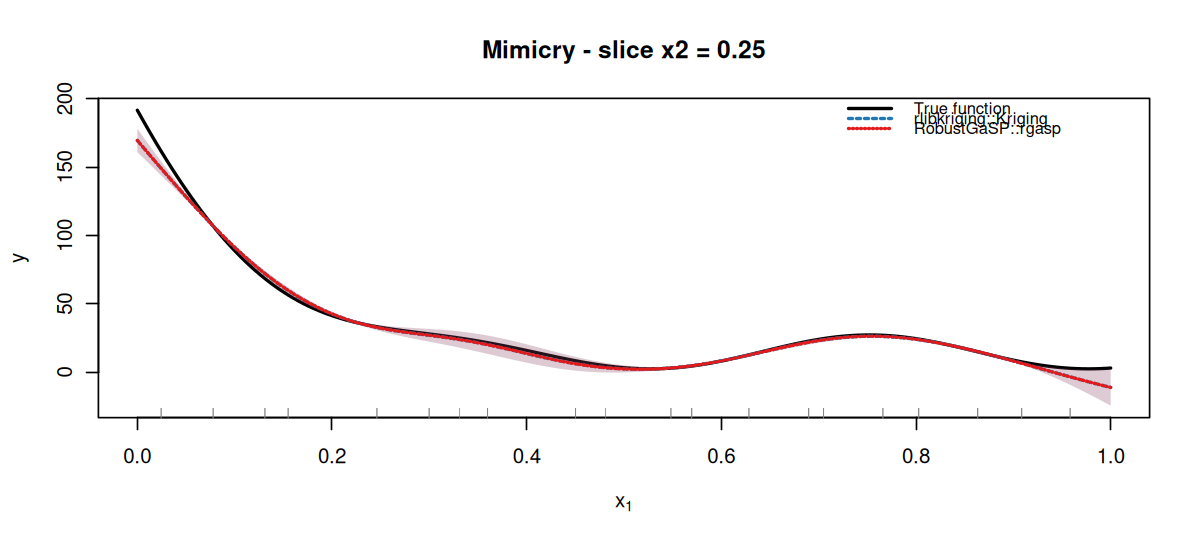

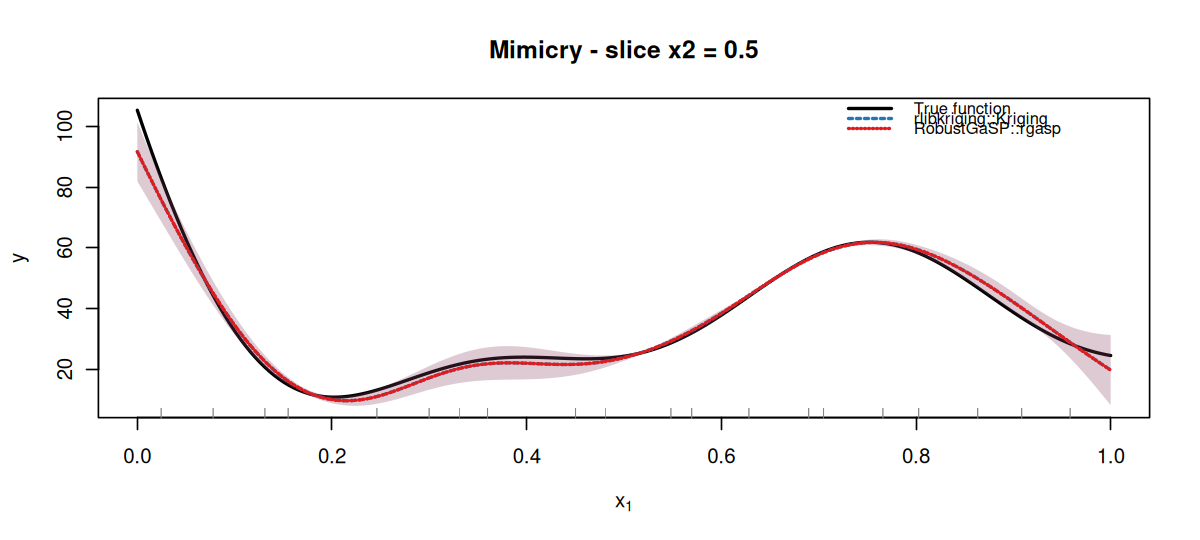

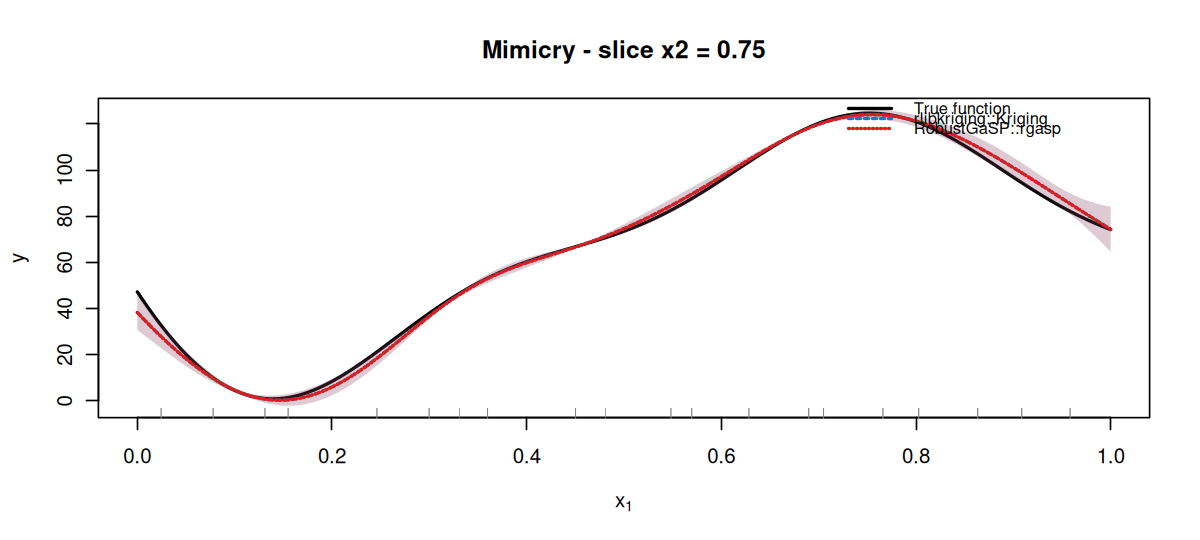

In [6]:
p_lk_full <- predict(k_lk, grid, return_stdev = TRUE)
p_rg_full <- predict(m_rg, grid)

cat("Max |mean_lk - mean_rg| :", max(abs(p_lk_full$mean - p_rg_full$mean)), "\n")
cat("Max |sd_lk   - sd_rg|   :", max(abs(p_lk_full$stdev - p_rg_full$sd)), "\n")

models_mimicry <- list(
  list(name = "rlibkriging::Kriging",
       pred = function(Xs) {
         p <- predict(k_lk, Xs, return_stdev = TRUE)
         list(mean = p$mean, sd = p$stdev)
       }),
  list(name = "RobustGaSP::rgasp",
       pred = function(Xs) {
         p <- predict(m_rg, Xs)
         list(mean = p$mean, sd = p$sd)
       })
)

plot_slices(models_mimicry, main_prefix = "Mimicry - ")


Both fits converge (up to optimizer precision) to essentially the same
hyperparameters and predictions: `rlibkriging::Kriging()` with `kernel =
"matern5_2", regmodel = "constant", objective = "LL"` faithfully reproduces
`RobustGaSP::rgasp(..., method = "mle")` — the mean curves and uncertainty
ribbons overlap almost exactly on every slice.

## 4. Package-specific feature: robust estimation via marginal posterior

Plain MLE range-parameter estimation is well known to be unstable on
small/sparse designs: the profile likelihood can be nearly flat along some
directions of the range-parameter space, so different (equally likely)
optimizer restarts can land on wildly different range estimates — one
direction collapsing towards 0 (pure interpolation / overfitting) while
another explodes towards infinity (near-linear extrapolation), long before
any of this is visible in the reported likelihood value.

RobustGaSP's answer (Gu, Wang & Berger, 2018) is to replace MLE by the
**marginal posterior mode** under a **jointly robust prior** on the
(inverse) range and nugget parameters (`method = "post_mode"`,
`prior_choice = "ref_approx"`, both the package's defaults) — a proper,
data-driven regularization that shrinks range estimates away from these
degenerate regimes. `rlibkriging`'s `objective = "LMP"` (Log Marginal
Posterior) is built on the same idea.

To make the effect visible, we deliberately use a **sparse** 2D design
(`n = 7`, well below the usual `n = 10*d` rule of thumb) where plain MLE is
most likely to misbehave, and compare the range parameters obtained by:

- plain MLE: `rgasp(..., method = "mle")` / `Kriging(..., objective = "LL")`
- robust estimation: `rgasp(..., method = "post_mode")` (default) /
  `Kriging(..., objective = "LMP")`

In [7]:
set.seed(123)
n_sparse <- 7
X_sparse <- lhs(n_sparse, 2)
y_sparse <- branin(X_sparse)

k_ll  <- Kriging(y_sparse, X_sparse, kernel = "matern5_2", regmodel = "constant",
                 optim = "BFGS10", objective = "LL")
k_lmp <- Kriging(y_sparse, X_sparse, kernel = "matern5_2", regmodel = "constant",
                 optim = "BFGS10", objective = "LMP")

invisible(capture.output({
  m_mle <- rgasp(design = X_sparse, response = matrix(y_sparse, ncol = 1),
                 kernel_type = "matern_5_2", method = "mle", num_initial_values = 10)
  m_pm  <- rgasp(design = X_sparse, response = matrix(y_sparse, ncol = 1),
                 kernel_type = "matern_5_2", method = "post_mode", num_initial_values = 10)
}))

ranges <- rbind(
  "rlibkriging LL  (MLE)"        = as.vector(k_ll$theta()),
  "rlibkriging LMP (robust)"     = as.vector(k_lmp$theta()),
  "RobustGaSP mle       (MLE)"   = 1 / m_mle@beta_hat,
  "RobustGaSP post_mode (robust)"= 1 / m_pm@beta_hat
)
colnames(ranges) <- c("range_x1", "range_x2")
print(round(ranges, 4))


                              range_x1 range_x2
rlibkriging LL  (MLE)           0.2042   7.6088
rlibkriging LMP (robust)        0.7517   1.5522
RobustGaSP mle       (MLE)      0.2041 465.5289
RobustGaSP post_mode (robust)   0.7517   1.5522


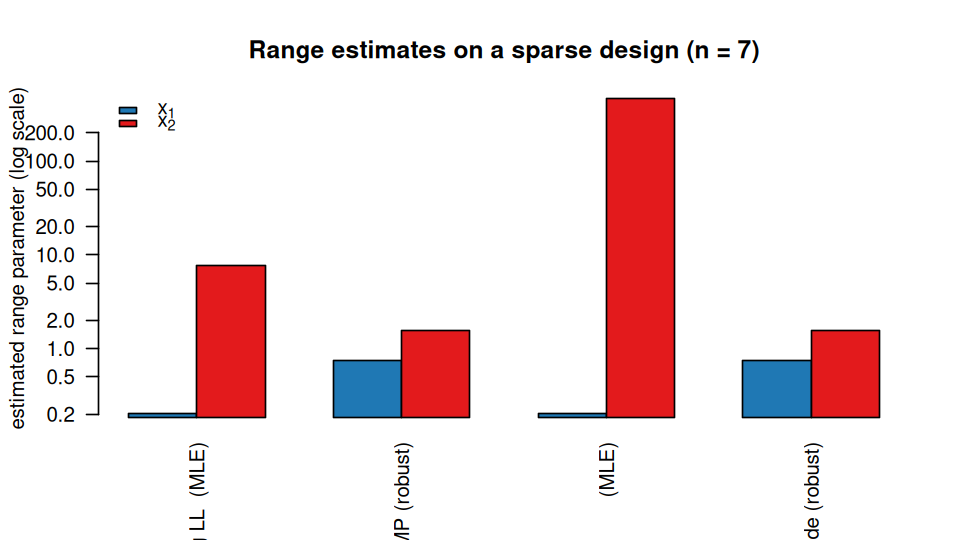

In [8]:
options(repr.plot.width = 8, repr.plot.height = 4.5)
barplot(t(ranges), beside = TRUE, log = "y",
        col = c("#1f78b4", "#e31a1c"), las = 2,
        ylab = "estimated range parameter (log scale)",
        main = paste0("Range estimates on a sparse design (n = ", n_sparse, ")"))
legend("topleft", legend = c(expression(x[1]), expression(x[2])),
       fill = c("#1f78b4", "#e31a1c"), bty = "n")


On this sparse design, plain MLE (both `objective = "LL"` and
`method = "mle"`) tends to produce a **large gap between the two range
estimates** — one direction stretched far beyond the design's extent while
the other stays comparatively short — reflecting the near-flat likelihood
ridge exploited differently by each optimizer restart. The robust
alternatives (`objective = "LMP"` and `method = "post_mode"`) instead pull
both range estimates towards the same, more moderate order of magnitude:
**`rlibkriging`'s LMP estimate lands remarkably close to RobustGaSP's own
`post_mode` estimate**, confirming both packages regularize the same way
for the same reason, even though `rlibkriging`'s plain-MLE (`"LL"`) fit
does not degenerate quite as severely as RobustGaSP's `"mle"` on this
particular draw (a difference in optimizer initial values / bounds
handling between the two implementations, not in the underlying
likelihood).

## 5. Argument correspondence table

| RobustGaSP `rgasp(...)` | rlibkriging equivalent | Notes |
|---|---|---|
| `kernel_type = "matern_5_2"` | `kernel = "matern5_2"` | also `"matern_3_2"` -> `"matern3_2"`; RobustGaSP's `"pow_exp"` has no direct libKriging equivalent |
| `trend = matrix(1, n, 1)` | `regmodel = "constant"` | constant trend (both defaults) |
| `method = "mle"` | `objective = "LL"` | plain maximum likelihood |
| `method = "post_mode"` (default) | `objective = "LMP"` | marginal posterior mode under a jointly robust prior — RobustGaSP's signature feature |
| `nugget.est = TRUE` | `noise = "nugget"` (on `Kriging`) | homogeneous nugget, estimated |
| `num_initial_values = k` | `optim = "BFGSk"` (e.g. `"BFGS10"`) | random optimizer restarts |
| `predict(model, testing_input)` | `predict(k, x, return_stdev = TRUE)` | `$mean` / `$sd` vs. `$mean` / `$stdev` |
| `beta_hat` (inverse range) | `theta()` (range) | `range = 1 / beta_hat` |

See `skills/libkriging/SKILL.md` and `skills/libkriging/references/r.md` for
the full decision guide (class, kernel, trend, objective) on the
`rlibkriging` side.